# Bedtime Phone Usage and Sleep Analysis

This project explores the relationship between bedtime phone usage, sleep duration, sleep latency, and next-day fatigue.

In [1]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\ASUS\Downloads\archive\bedtime_screentime_sleep_debt.csv"
)
print(df.shape) 
df.head(5)

(8500, 18)


,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [2]:
#check data
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

np.int64(0)

In [3]:
columns = [
    "bedtime_phone_minutes",
    "sleep_latency_min",
    "total_sleep_hours",
    "next_day_fatigue_score"
]
df[columns].describe()

,bedtime_phone_minutes,sleep_latency_min,total_sleep_hours,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000
mean,59.250000,40.671471,6.266209,3.794671
std,36.931991,17.444914,1.446258,2.685153
min,1.000000,6.000000,3.200000,1.000000
25%,31.000000,28.200000,5.240000,1.100000
50%,51.000000,37.600000,6.330000,3.200000
75%,79.000000,49.700000,7.350000,5.600000
max,180.000000,123.300000,9.800000,10.000000


In [4]:
#define screen-time group boundaries
bins = [0, 30, 60, 120, float("inf")]

#define English names for each group
labels = [
    "1-30 minutes",
    "31-60 minutes",
    "61-120 minutes",
    "More than 120 minutes"
]

#Assign each person to a screen-time group
df["phone_usage_group"] = pd.cut(
    df["bedtime_phone_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate summary statistics for each group
summary = (
    df.groupby("phone_usage_group", observed=False)
    .agg(
        number_of_people=("user_id", "count"),
        average_sleep_hours=("total_sleep_hours", "mean"),
        average_sleep_latency_minutes=("sleep_latency_min", "mean"),
        average_fatigue_score=("next_day_fatigue_score", "mean")
    )
    .round(2)
    .reset_index()
)

summary

,phone_usage_group,number_of_people,average_sleep_hours,average_sleep_latency_minutes,average_fatigue_score
0,1-30 minutes,2051,7.15,25.04,1.93
1,31-60 minutes,3038,6.58,34.79,2.88
2,61-120 minutes,2773,5.68,50.44,5.13
3,More than 120 minutes,638,4.45,76.47,8.36


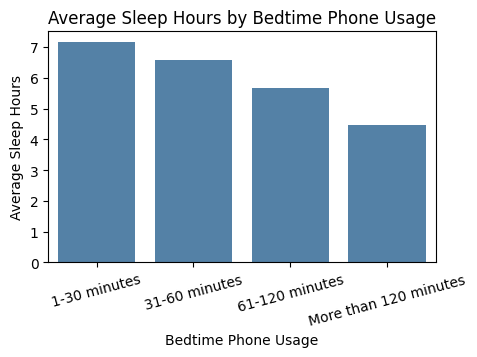

In [5]:
# Check whether longer phone use before bedtime is associated with fewer hours of sleep
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))

sns.barplot(
    data=summary,
    x="phone_usage_group",
    y="average_sleep_hours",
    color="steelblue"
)

plt.title("Average Sleep Hours by Bedtime Phone Usage")
plt.xlabel("Bedtime Phone Usage")
plt.ylabel("Average Sleep Hours")
plt.xticks(rotation=15)

plt.show()

## Finding 1

People who spent more time using their phones before bedtime had fewer average sleep hours. The group using their phones for more than 120 minutes had the lowest average sleep duration.

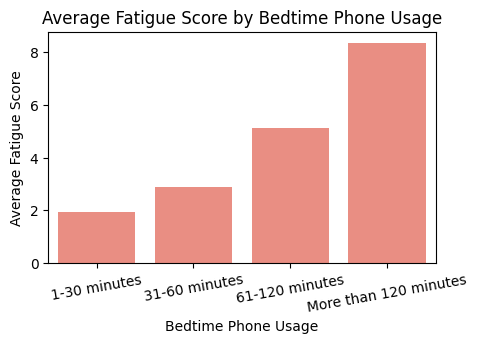

In [6]:
# Check whether longer phone use before bedtime is associated with higher fatigue levels the next day
plt.figure(figsize=(5, 3))

# Create a bar chart using the summary table
sns.barplot(
    data=summary,                    
    x="phone_usage_group",           
    y="average_fatigue_score",       
    color="salmon"                   
)

# Add the detail of chart
plt.title("Average Fatigue Score by Bedtime Phone Usage")
plt.xlabel("Bedtime Phone Usage")
plt.ylabel("Average Fatigue Score")
plt.xticks(rotation=10)
plt.show()

## Finding 2

People who spent more time using their phones before bedtime had higher fatigue scores the next day. The group using their phones for more than 120 minutes had the highest average fatigue score.

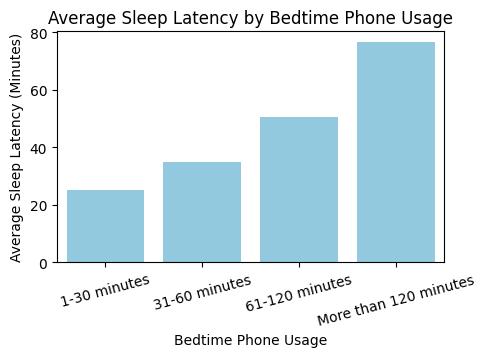

In [7]:
# Check the relationship between phone use and sleep latency
plt.figure(figsize=(5, 3))

# Create the bar chart
sns.barplot(
    data=summary,
    x="phone_usage_group",
    y="average_sleep_latency_minutes",
    color="skyblue"
)

# Add chart details
plt.title("Average Sleep Latency by Bedtime Phone Usage")
plt.xlabel("Bedtime Phone Usage")
plt.ylabel("Average Sleep Latency (Minutes)")
plt.xticks(rotation=15)

# Display the chart
plt.show()

## Finding 3

People who spent more time using their phones before bedtime also took longer to fall asleep. The group using their phones for more than 120 minutes had the highest average sleep latency.

In [8]:
# Summarize sleep results by bedtime app
app_summary = (
    df.groupby("primary_bedtime_app")
    .agg(
        number_of_people=("user_id", "count"),
        average_sleep_hours=("total_sleep_hours", "mean"),
        average_fatigue_score=("next_day_fatigue_score", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("average_sleep_hours", ascending=False)
)

# Display the summary table
app_summary

,primary_bedtime_app,number_of_people,average_sleep_hours,average_fatigue_score
2,News / Reading,596,6.38,3.33
3,Streaming (Netflix/Hulu),1301,6.36,3.45
1,Messaging / Chat,847,6.33,3.59
5,YouTube,1928,6.30,3.72
0,Instagram / Reddit,1630,6.21,3.94
4,TikTok / Reels,2198,6.17,4.16


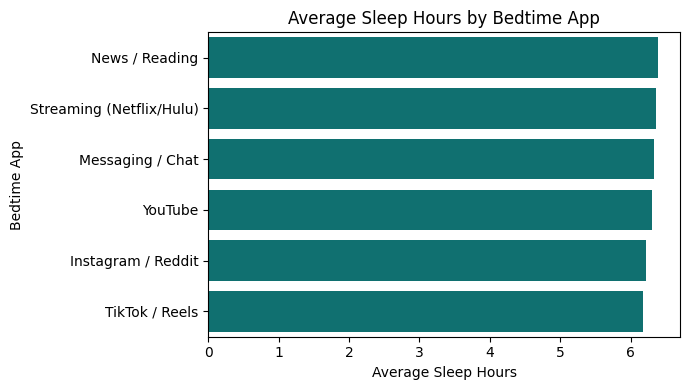

In [9]:
# Compare average sleep duration across bedtime apps
plt.figure(figsize=(7, 4))

# Create a horizontal bar chart
sns.barplot(
    data=app_summary,
    x="average_sleep_hours",
    y="primary_bedtime_app",
    color="teal"
)

# Add chart details
plt.title("Average Sleep Hours by Bedtime App")
plt.xlabel("Average Sleep Hours")
plt.ylabel("Bedtime App")

# Display the chart
plt.tight_layout()
plt.show()

## Finding 4

Average sleep duration varied across bedtime apps. However, the differences between the app groups were relatively small compared with the differences between phone usage duration groups.

## Conclusion

This analysis found a clear relationship between bedtime phone usage and sleep outcomes. People who used their phones for longer before going to bed tended to sleep fewer hours, take longer to fall asleep, and experience greater fatigue the following day.

The type of bedtime app was also associated with some differences in sleep duration, although these differences were smaller than those observed between phone-usage-duration groups.

Overall, the results suggest that reducing phone use before bedtime may be associated with better sleep. However, this analysis shows association rather than causation, so it cannot prove that phone use directly causes poor sleep.